# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [2]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



### Cargar Dataset

In [3]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [4]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [5]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int')


In [6]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [7]:
# Estadísticas descriptivas de variables numéricas
df.describe()


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — El analisis se hace con la gente mayor de edad. van de 18-75 anos. La media y mediana son muy parecidas, lo que me lleva a pensar que hay una distribucion normal de los datos
- `ingreso_anual` - se observa que el 25% de las compras no aportan al ingreso_anual
- `nivel_ingreso` - la media y mediana son muy parecidas y se ve una diferencia importante entre el 75% y el maximo. Quizas sea un dato atipico
- `visitas_mes`- posibles datos atipicos en el maximo. Media y mediana parecidas
- `compras_mes`- el comportamiento es muy parecido a la columna ingreso_anual

#### Explorar variables binarias

In [8]:
# Verificar que cada columna tenga únicamente dos valores posibles
df[['miembro_premium', 'abandono']].nunique()

print("miembro_premium:")
print(df['miembro_premium'].value_counts())
print("\nabandono:")
print(df['abandono'].value_counts())


miembro_premium:
0    12911
1     2089
Name: miembro_premium, dtype: int64

abandono:
0    12739
1     2261
Name: abandono, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — El 86% de los miembros no son premium
- `abandono` — El 15% si abandono

#### Explorar variables categóricas

In [9]:
# Verificar el número de valores únicos por variable categórica
print("Valores únicos en tipo_dispositivo:")
print(df['tipo_dispositivo'].unique())

print("\nValores únicos en region:")
print(df['region'].unique())

Valores únicos en tipo_dispositivo:
['móvil' 'tablet' 'escritorio']

Valores únicos en region:
['norte' 'sur' 'este' 'oeste']


In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("Distribución de tipo_dispositivo:")
print(df['tipo_dispositivo'].value_counts())
print("Distribución de regiones:")
print(df['region'].value_counts())

Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64
Distribución de regiones:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — El 65% de los datos se encuentra en los dispositivos moviles
- `region` - el 29.3% de los datos se encuentra en la region norte

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

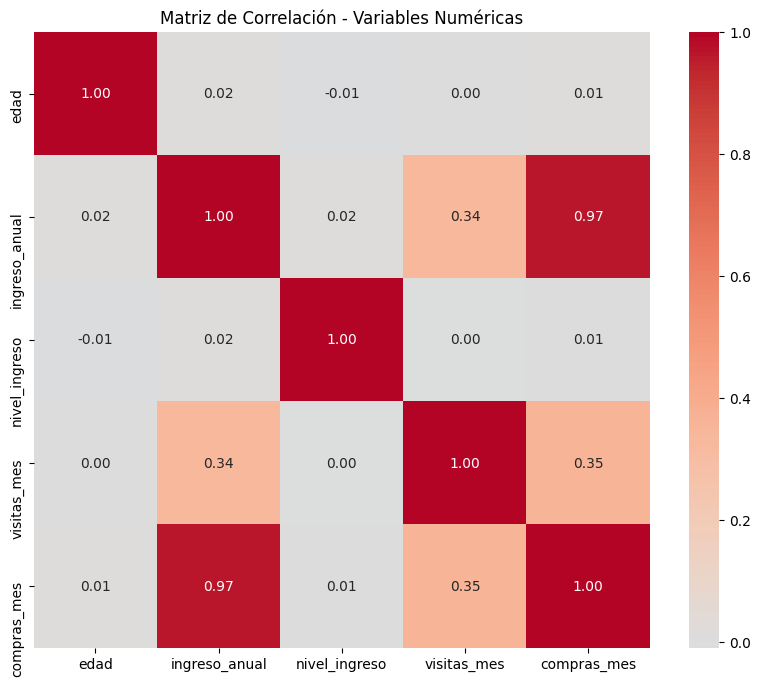

In [11]:
# Visualizar la matriz de correlación para identificar relaciones
variables_numericas = ['edad', 'ingreso_anual', 'nivel_ingreso', 'visitas_mes', 'compras_mes']
matriz_correlacion = df[variables_numericas].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, 
            annot=True,           # Mostrar los valores de correlación
            cmap='coolwarm',      # Esquema de colores
            center=0,             # Centrar en 0
            square=True,          # Hacer las celdas cuadradas
            fmt='.2f')            # Formato de 2 decimales
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa una correlacion entre compras_mes e ingreso_anual y visitas_mes con ingreso_anual


Observaciones respecto a `ingreso_anual`  
- Presenta una correlacion alta con compras_mes lo que tiene sentido, entre mas compras, mas ingresos


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué: No veo necesario incluirlo ya que en el heatmapse ven claramente las relaciones (compras_mes vs ingreso_anual)

### Scatterplot para pares clave

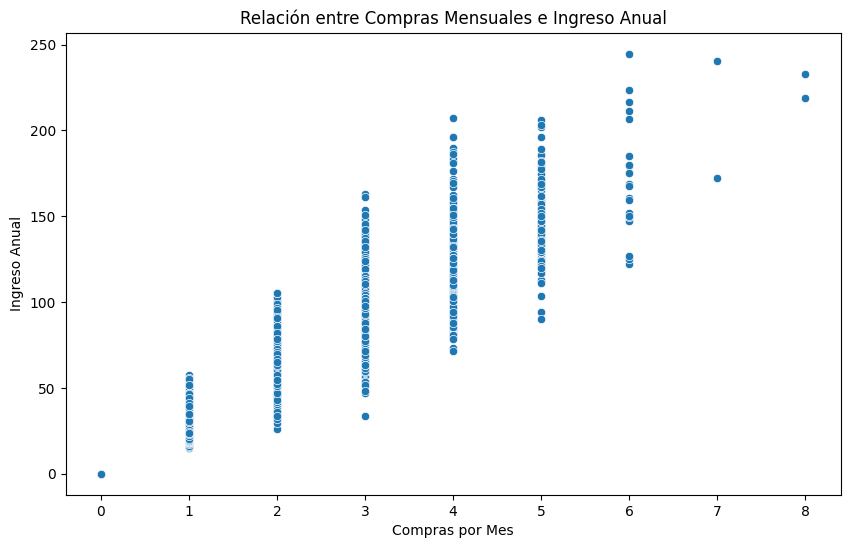

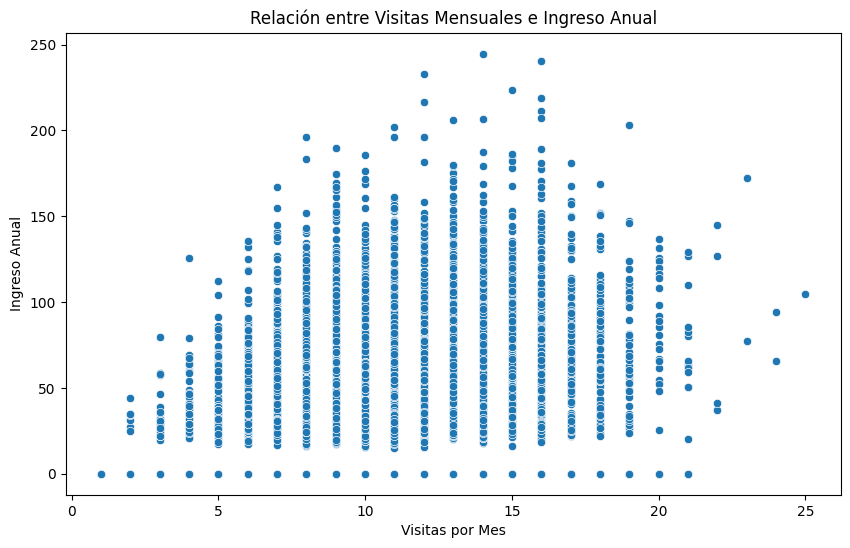

In [12]:
# Visualizar pares de variables con relaciones moderadas o fuertes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual')
plt.title('Relación entre Compras Mensuales e Ingreso Anual')
plt.xlabel('Compras por Mes')
plt.ylabel('Ingreso Anual')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual')
plt.title('Relación entre Visitas Mensuales e Ingreso Anual')
plt.xlabel('Visitas por Mes')
plt.ylabel('Ingreso Anual')
plt.show()


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**var1 vs var2**
- Dirección lineal positiva, con unos cuantos outliers...
- 

**var1 vs var3**
- Dirección positiva pero relacion debil
- Alta dispersion formando nube de puntos
- Relacion menos clara- 

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [13]:
# Calcular correlación entre variables relevantes
def corr_numerica(df, variables_numericas, method):
    correlaciones = df[variables_numericas].corr(method=method)
    return correlaciones

print("=== CORRELACIÓN DE PEARSON ===")
pearson_corr = corr_numerica(df, variables_numericas, 'pearson')
print(pearson_corr)

print("\n=== CORRELACIÓN DE SPEARMAN ===")
spearman_corr = corr_numerica(df, variables_numericas, 'spearman')
print(spearman_corr)

=== CORRELACIÓN DE PEARSON ===
                   edad  ingreso_anual  nivel_ingreso  visitas_mes  \
edad           1.000000       0.017496      -0.009003     0.004998   
ingreso_anual  0.017496       1.000000       0.017446     0.337147   
nivel_ingreso -0.009003       0.017446       1.000000     0.001060   
visitas_mes    0.004998       0.337147       0.001060     1.000000   
compras_mes    0.014971       0.967149       0.007309     0.353844   

               compras_mes  
edad              0.014971  
ingreso_anual     0.967149  
nivel_ingreso     0.007309  
visitas_mes       0.353844  
compras_mes       1.000000  

=== CORRELACIÓN DE SPEARMAN ===
                   edad  ingreso_anual  nivel_ingreso  visitas_mes  \
edad           1.000000       0.016097      -0.007775     0.005205   
ingreso_anual  0.016097       1.000000       0.025017     0.320954   
nivel_ingreso -0.007775       0.025017       1.000000     0.001420   
visitas_mes    0.005205       0.320954       0.001420     1.0

In [14]:
# Calcular correlación entre variables relevantes


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**var1 vs var2**
- Correlación entre ingreso_anual y compras_mes sigue teniendo una correlacion alta de 0.96 en los 2 metodos
  

**var2 vs var3**
- Correlación sigue siendo moderada entre ingreso_anual y visitas_mes
  

### Punto-biserial

In [15]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

def correlacion_punto_biserial(df, var_binaria, var_numerica):
       # Eliminar valores nulos
    datos_limpios = df[[var_binaria, var_numerica]].dropna()
    
    # Calcular correlación
    corr, p_value = pointbiserialr(datos_limpios[var_binaria], 
                                   datos_limpios[var_numerica])
    
    return corr, p_value
corr, p_value = correlacion_punto_biserial(df, 'abandono', 'ingreso_anual')
print(f"Correlación punto-biserial entre abandono e ingreso_anual:")
print(f"Correlación: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

corr, p_value = correlacion_punto_biserial(df, 'miembro_premium', 'ingreso_anual')
print(f"Correlación punto-biserial entre miembro_premium e ingreso_anual:")
print(f"Correlación: {corr:.4f}")
print(f"P-value: {p_value:.4f}")


Correlación punto-biserial entre abandono e ingreso_anual:
Correlación: -0.0028
P-value: 0.7295
Correlación punto-biserial entre miembro_premium e ingreso_anual:
Correlación: 0.0931
P-value: 0.0000


In [20]:
# Correlación punto-biserial entre abandono y satisfacción
corr, p_value = correlacion_punto_biserial(df, 'abandono', 'satisfaccion')
print(f"Correlación punto-biserial entre abandono y satisfacción:")
print(f"Correlación: {corr:.4f}")
print(f"P-value: {p_value:.4f}")
print("Satisfacción promedio por grupo:")
print(df.groupby('abandono')['satisfaccion'].agg(['mean', 'std', 'count']))

Correlación punto-biserial entre abandono y satisfacción:
Correlación: -0.0238
P-value: 0.0035
Satisfacción promedio por grupo:
              mean       std  count
abandono                           
0         3.610574  0.683005  12739
1         3.564927  0.696975   2261


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**var1 vs var2**
- la relacion entre el abandono y el ingreso anual, vemos que es casi nulo. Lo que lleva a que mi hipotesis es erronea(Pensaba que quizas el abandono estaba relacionado con el ingreso anual de usuarios)

**var2 vs var3**
- Relación positiva debil entre miembro_premium e ingreso_anual. Lo que nos quiere decir que hay una influencia debil entre estas dos columnas

### V de Cramér

In [16]:
# Función para calcular V de Cramér
def cramers_v(x, y):
  
    from scipy.stats import chi2_contingency
    import numpy as np
    
    # Crear tabla de contingencia
    confusion_matrix = pd.crosstab(x, y)
    
    # Calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(confusion_matrix)
    
    # Calcular V de Cramér
    n = confusion_matrix.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))
    
    return cramers_v, p_value


In [17]:
# Aplicar V de Cramér en variables relevantes
v_cramer, p_value = cramers_v(df['tipo_dispositivo'], df['region'])

print(f"V de Cramér entre tipo_dispositivo y region:")
print(f"V de Cramér: {v_cramer:.4f}")
print(f"P-value: {p_value:.4f}")



V de Cramér entre tipo_dispositivo y region:
V de Cramér: 0.0124
P-value: 0.5965


In [18]:
#Validar relacion entre abandono y tipo de dispositivo
from scipy.stats import chi2_contingency

# Test chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(df['abandono'], df['tipo_dispositivo']))
print(f"Chi-cuadrado: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")


Chi-cuadrado: 0.7874
P-value: 0.6746


In [19]:
# V de Cramér para abandono vs tipo_dispositivo
v_cramer_abandono_dispositivo, p_value_abandono_dispositivo = cramers_v(df['abandono'], df['tipo_dispositivo'])
print(f"V de Cramér entre abandono y tipo_dispositivo:")
print(f"V de Cramér: {v_cramer_abandono_dispositivo:.4f}")
print(f"P-value: {p_value_abandono_dispositivo:.4f}")

print("\n" + "="*50 + "\n")

# V de Cramér para abandono vs región
v_cramer_abandono_region, p_value_abandono_region = cramers_v(df['abandono'], df['region'])
print(f"V de Cramér entre abandono y región:")
print(f"V de Cramér: {v_cramer_abandono_region:.4f}")
print(f"P-value: {p_value_abandono_region:.4f}")

V de Cramér entre abandono y tipo_dispositivo:
V de Cramér: 0.0072
P-value: 0.6746


V de Cramér entre abandono y región:
V de Cramér: 0.0154
P-value: 0.3117


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér: el tipo de dispositivo utilizado pour los usuarios es independiente de la region en donde se encuentran
]


In [21]:
# Tabla de contingencia
tabla_contingencia = pd.crosstab(df['abandono'], df['miembro_premium'], margins=True)
print("Tabla de contingencia - Abandono vs Miembro Premium:")
print(tabla_contingencia)
# Porcentajes por fila (qué porcentaje de cada grupo abandona)
porcentajes = pd.crosstab(df['abandono'], df['miembro_premium'], normalize='columns') * 100
print("\nPorcentaje de abandono por tipo de membresía:")
print(porcentajes)

Tabla de contingencia - Abandono vs Miembro Premium:
miembro_premium      0     1    All
abandono                           
0                10741  1998  12739
1                 2170    91   2261
All              12911  2089  15000

Porcentaje de abandono por tipo de membresía:
miembro_premium          0          1
abandono                             
0                83.192626  95.643849
1                16.807374   4.356151


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — Correlacion muy fuerte entre compras_mes e ingreso_anual (0.967)

**Evidencia visual:**   
Scatterlpot que nos muestra una correlacion lineal positiva
**Evidencia numérica:**
Tenemos Correlación de Pearson: 0.967 y Correlación de Spearman: 0.967

**Interpretación**  
Con estas 2 evidencias, podemos notar que entre compras_mes e ingreso_anual, presentan una fuerte correlacion lineal positiva. 

**No podemos afirmar**  
No podemos afirmar que hay causalidad

**Implicación de negocio**  
Este hallazgo nos permite responder a la pregunta inicial: Que factores del comportamiento del client estan fuertemente asociados con el ingreso anual generado  entonces se podrian hacer programas de reconocimiento por permanencia en la plataforma o mayores rebajas por volumen de compra.


### Hallazgo 2 — Comportamiento entre abandono vs miembros_premium

**Evidencia visual:**   
**Evidencia numérica:** 
Usuarios NO premium (0): 16.8% de abandono
Usuarios premium (1): 4.4% de abandono

**Interpretación**  
Los usuarios premium son menos propensos a abandonar la plataforma. 
**No podemos afirmar** 
- ¿Qué beneficios específicos ofrece la membresía premium?
- ¿Cuál es el costo de la membresía premium?
- ¿Qué servicios adicionales reciben?
- ¿Hay descuentos especiales o envío gratuito?


**Implicación de negocio** 
Esto sugiere que la membresía premium podría estar asociada con mayor retención. Quizas algo en el plan que ofrezca ventajas que los regulares no tienen


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- El dataset no proporciona información sobre las características específicas del programa premium que explican la menor tasa de abandono (4.4% vs 16.8%)
- Seria importante saber:
 Costo de la membresía premium
 Ingresos/perfil socioeconómico de los clientes
 Beneficios específicos del programa
-Vincular mas anos en el analisis
### **Próximos pasos** 

Diferencia de abandono miembro premium vs regular 
1. Investigación cualitativa de abandono

Contactar miembros que abandonaron la plataforma
Identificar razones específicas de abandono y conocimiento de beneficios premium
Determinar tiempo promedio hasta abandono (ej. 6 meses)
2. Experimento controlado de retención

Población objetivo: Miembros regulares de 1-3 meses de antigüedad
Justificación: Intervenir antes del período crítico de abandono
Metodología: Ofrecer beneficios premium seleccionados basados en hallazgos de fase 1
Seguimiento: 6 meses para evaluar retención vs grupo control



